
# Femicide Count Kenya: Technical Challenge

This notebook provides a structure for solving the classification task using SwahBERT.
The key objectives include:
- Exploring and understanding the dataset.
- Training a multi-class logistic regression model using SwahBERT embeddings.
- Evaluating the model using metrics like Accuracy, F1 Score, and AUPR.

---
**Note**: Customize this template as needed. Happy modeling!
    


## Setup Environment

This section includes instructions to set up Google Colab and mount Google Drive to access the data and SwahBERT model.

1. Create a shortcut for the `femicide_count_kenya_tech_challenge` folder in your Google Drive.
2. Run the cells below to mount your Drive and set the path variables.
    

In [2]:
import pandas as pd
import os
from IPython.display import display_html
import matplotlib

In [3]:
# Define paths for the dataset and SwahBERT model
swahbert_path = 'swahbert'
train_data_path = 'classification_data/train.csv'
test_data_path = 'classification_data/test.csv'


import pandas as pd
# Data Exploration
# Load the datasets
train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)

# Display basic information
print("Training Data Overview:")
print(train_data.head())
print("
Class Distribution in Training Data:")
print(train_data['label'].value_counts())

# Check for missing values
print("
Missing Values:")
print(train_data.isnull().sum())
    


## Data Exploration

#Load the dataset and explore its structure, distribution of classes, and basic characteristics.

### Tasks:
- Display the first few rows of the dataset.
- Check for missing values.
- Visualize the class distribution.

In [4]:
# Load the datasets
news_train_data = pd.read_csv(train_data_path)
news_test_data = pd.read_csv(test_data_path)

# Convert the first 5 rows of both datasets to HTML tables
train_html = news_train_data.head().to_html()
test_html = news_test_data.head().to_html()

# Combine the HTML tables side by side
combined_html = f"""
<div style="display: flex; flex-direction: row; justify-content: space-around;">
    <div>
        <h3>Train Data</h3>
        {train_html}
    </div>
    <div>
        <h3>Test Data</h3>
        {test_html}
    </div>
</div>
"""

# Display the side-by-side tables in Colab
display_html(combined_html, raw=True)

Train Data 
 
 
 
 
 text 
 label 
 
 
 
 
 0 
 Bodi ya Utalii Tanzania (TTB) imesema, itafanya misafara ya kutangaza utalii kwenye miji minne nchini China kati ya Juni 19 hadi Juni 26 mwaka huu.Misafara hiyo itatembelea miji ya Beijing Juni 19, Shanghai Juni 21, Nanjig Juni 24 na Changsha Juni 26.Mwenyekiti wa bodi TTB, Jaji Mstaafu Thomas Mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini Dar es Salaam.“Tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka China hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini,” amesema Jaji Mihayo.Novemba 2018 TTB ilifanya ziara kwenye miji ya Beijing, Shanghai, Chengdu, Guangzhou na Hong Kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za Air Tanzania.Ziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini Mei mwaka huu kutembelea vivutio vya utalii. 
 uchumi 
 
 
 1 
 PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, ametangaza kuwafukuza\nkazi wakurugenzi wote wa halmashauri ambao watabainika kukiuka sheria ya\nufutaji wa tozo za ushuru wa mazao. Alisema baada ya kuingia madarakani, Serikali\niliondoa tozo 80, miongoni mwa hizo tozo ushuru wakulima ambao walikuwa\nwakilipa mazao kutoka halmashauri moja kwenda nyingine. Rais Dk. Magufuli, aliyasema hayo juzi alipokuwa\nakiwahutubia wakazi wa Wilaya ya Kyela katika ziara ya kikazi ya siku 10 mkoani\nMbeya. Alisema, sheria ya ufutaji wa tozo hizo\nzilipitishwa na Bunge hivyo hakuna mtu yoyote wa kuitengua na kwamba Mkurugenzi\natakaye itengua atakuwa umevunja sheria na anawajibu wa kufukuzwa kazi. Alisema licha ya kupitishwa kwa sheria hiyo wapo\nbaadhi ya watendaji wameendelea kuwatoza ushuru wananchi kwa kisingizio cha\nkupandisha ukusanyaji wa mapato hilo jambo sitaki kulisikia. “Wapo watendaji\nwanasema kufutwa kwa ushuru kunapunguza mapato, narudia kwa viongozi wote, wakurugenzi,\nwatendaji wote wa halmashauri msiwatoze wananchi ushuru wa mzigo wowote usio\nzidi tani moja,”alisema. Hata hivyo, alitoa wito kwa watendaji kuzingatia\nsheria ya kuwalinda wakulima na ndio maana serikali iliziondoa tozo 80. 
 kitaifa 
 
 
 2 
 Mwandishi Wetu -Singida BENKI ya NMB imetoa msaada wa vifaa mbalimbali vyenye thamani ya zaidi ya Sh milioni 200 katika wilaya kadhaa nchini. Misaada iliyotolewa na benki hiyo inayoongoza kwa kutengeneza faida kati ya benki zote zinazofanya biashara humu nchini ndani ya miezi mitano mwaka huu, inahusisha vifaa vya ujenzi, madawati na vifaa vingine vinavyowezesha ukamilishaji wa miradi ya afya,elimu na usalama wa raia. Benki  ya NMB imeshatoa  msaada wa  vifaa vyenye thamani ya zaidi ya Sh milioni 200 kwa mikoa ya Kanda ya Kati. Akifafanua kuhusu misaada hiyo wakati akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule katika Halmashauri ya Wilaya ya Iramba mkoani ingida, Meneja wa Kanda ya Kati wa NMB, Nsolo Mlozi, alibainisha kuwa misaada hiyo ya zaidi ya Sh milioni 200 iliyotolewa imelenga sekta ya elimu, afya  na majanga kwa mikoa mitatu ya  Kanda ya kati. Akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule za Halmashauri ya Wilaya ya Iramba, MkoaniSingida, katika shule ya Sekondari ya New Kiomboi, Mlozi alisema fedha hizo zilizotolewa na NMB zimetumika kununua madawati, viti vya shule za sekondari,vitanda na vifaa tiba kwenye sekta ya afya. Aidha, alisema lengo la misaada hiyo ni kuunga mkono juhudi za serikali kuwahudumia wananchi kwenye sekta mbalimbali. Pia alisema misaada hiyo imekabidhiwa kwa baadhi ya shule, zahanati, hospitali katika mikoa ya Singida, Dodoma na Manyara. Pia NMB walikabidhi madawati 250 na vitanda 80 vyenye thamani ya zaidi ya Sh milioni 29.5 kwa baadhi ya shule za Wilaya ya Iramba mkoani humo. Katika hatua nyingine, Benki hiyo imevipatia kituo cha Polisi Wilaya ya Kilosa mkoani Morogoro pamoja na shule ya msingi Msowelo mabati 160 yenye thamani ya Sh5 milioni kwa ajili ya kuezekea maboma. NMB iliamua kutoa msaada huo ikiwa ni mpango wa kuzipunguza baadhi ya changamoto kwa taasisi za serikal

In [5]:
print("Training data shape =>", news_train_data.shape)
print("Test data shape =>", news_test_data.shape)

Training data shape => (22207, 2)
Test data shape => (7338, 2)


In [6]:
# print("Training Data Overview:")
# print(train_data.head())
print("Class Distribution in Training Data:")
print(news_train_data['label'].value_counts())

Class Distribution in Training Data:
label
kitaifa      10155
michezo       5970
burudani      2185
kimataifa     1858
uchumi        1260
afya           779
Name: count, dtype: int64


<Axes: xlabel='label'>

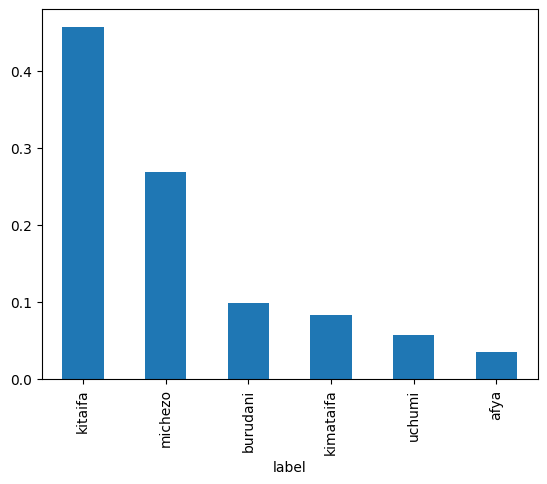

In [7]:
# Training data labels relative distribution
news_train_data['label'].value_counts(normalize=True).plot.bar()

In [8]:
# Check for missing values in Train & Test dataset
print("Missing values in Train Data:")
print(news_train_data.isnull().sum())

print("\nMissing values in Test Data:")
print(news_test_data.isnull().sum())


Missing values in Train Data:
text     1
label    0
dtype: int64

Missing values in Test Data:
text     0
label    0
dtype: int64


# Data Preprosessing

In [9]:

## Preprocessing

#Perform data cleaning and prepare the dataset for SwahBERT embeddings.

### Tasks:
#- Tokenize and preprocess the text data.
#- Handle missing or noisy data if necessary.


In [10]:
# Preparing the labels
# Retrieving SwahBERT embeddings
# Preprocess news texts with SwahBERT
# Data splitting

In [11]:
# Drop rows with missing values in news_train_data
news_train_data = news_train_data.dropna()

# Display new shapes of datasets
print("\nNew Train Data Shape:", news_train_data.shape)
print("New Test Data Shape:", news_test_data.shape)


New Train Data Shape: (22206, 2)
New Test Data Shape: (7338, 2)


In [12]:
# remove non-textual content
import re

# Example: Clean a text column
news_train_data['text'] = news_train_data['text'].apply(lambda x: re.sub(r'[^a-zA-Z\u00C0-\u017F\s]', '', x))  # Keeps Swahili characters and spaces
news_test_data['text'] = news_test_data['text'].apply(lambda x: re.sub(r'[^a-zA-Z\u00C0-\u017F\s]', '', x))


In [13]:
# normalise text for uniformity

news_train_data['text'] = news_train_data['text'].str.lower()
news_test_data['text'] = news_test_data['text'].str.lower()


Best Practices with SwahBERT:

    Leave Stop Words: If you're using SwahBERT embeddings, you might not need to remove stop words since the model can handle them contextually.
    Remove Stop Words: If you're working with classic models (e.g., TF-IDF + Logistic Regression), removing stop words can be beneficial.
    

In [14]:
news_train_data['text']

0         bodi ya utalii tanzania ttb imesema itafanya ...
1         pendo fundishambeya rais dk john magufuri ame...
2        mwandishi wetu singida benki ya nmb imetoa msa...
3         timu ya taifa ya tanzania serengeti boys jana...
4         na agatha charles  dar es salaam aliyekuwa ka...
                               ...                        
22202     alitoa pongezi hizo alipozindua rasmi hatua y...
22203     na nora damiandar es salaam  tekla si jina la...
22204     mkuu wa mkoa wa njombe dk rehema nchimbi waka...
22205     mabingwa wa ligi kuu soka tanzania bara simba...
22206     wiki iliyopita nilianza makala haya yanayolen...
Name: text, Length: 22206, dtype: object

SwahBERT uses tokenization and embeddings for text processing. You need to prepare the text so it aligns with SwahBERT's requirements.
When tokenizing your data, the Hugging Face tokenizer automatically generates the attention_mask if you enable padding. The attention_mask ensures the model focuses only on the meaningful parts of the input.


from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import time

# Load model
tokenizer = AutoTokenizer.from_pretrained(swahbert_path)
model = AutoModel.from_pretrained(swahbert_path, ignore_mismatched_sizes=True)
model.resize_token_embeddings(len(tokenizer))

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def process_texts(texts):
    batch_size = 16
    all_embeddings = []
    total = len(texts)
    
    for i in range(0, total, batch_size):
        # Print progress
        print(f"Processing batch {i//batch_size + 1}/{(total-1)//batch_size + 1}", end='\r')
        
        # Get batch texts
        batch_texts = texts[i:i + batch_size]
        
        # Tokenize
        encodings = tokenizer(
            batch_texts, 
            truncation=True, 
            padding=True, 
            max_length=128, 
            return_tensors="pt"
        )
        
        # Move to device
        encodings = {k: v.to(device) for k, v in encodings.items()}
        
        # Get embeddings
        with torch.no_grad():
            outputs = model(**encodings)
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(embeddings)
        
        # Clear memory
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    print("\nProcessing complete!")
    return np.concatenate(all_embeddings)

# Process training data
print("Processing training data...")
start_time = time.time()
train_embeddings = process_texts(news_train_data['text'].tolist())
np.save("train_embeddings.npy", train_embeddings)
print(f"Training data processed in {(time.time() - start_time):.2f} seconds")
print(f"Train embeddings shape: {train_embeddings.shape}")

# Clear memory before test data
del train_embeddings
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# Process test data
print("\nProcessing test data...")
start_time = time.time()
test_embeddings = process_texts(news_test_data['text'].tolist())
np.save("test_embeddings.npy", test_embeddings)
print(f"Test data processed in {(time.time() - start_time):.2f} seconds")
print(f"Test embeddings shape: {test_embeddings.shape}")

SwahBERT works with numerical labels for classification tasks. You should encode categorical labels into integers using a method such as LabelEncoder.

In [15]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit and transform labels in train and test datasets
news_train_data['label'] = label_encoder.fit_transform(news_train_data['label'])
news_test_data['label'] = label_encoder.transform(news_test_data['label'])

# Convert labels to tensors (required for PyTorch or TensorFlow models)
import torch
y_train = torch.tensor(news_train_data['label'].values)
y_test = torch.tensor(news_test_data['label'].values)

# Check unique encoded labels
print("Encoded labels:", label_encoder.classes_)


Encoded labels: ['afya' 'burudani' 'kimataifa' 'kitaifa' 'michezo' 'uchumi']


Adjusting class weights to deal with class imbalance:
Ideal for pre-trained models like SwahBERT where you don't want to modify the dataset. This is done on the training dataset only.



In [16]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(news_train_data['label']),
    y=news_train_data['label']
)

# Convert class weights into a dictionary
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)


Class Weights: {0: np.float64(4.7509627727856225), 1: np.float64(1.6938215102974827), 2: np.float64(1.9919268030139936), 3: np.float64(0.3644510093549975), 4: np.float64(0.6199329983249581), 5: np.float64(2.9396346306592536)}


In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the saved embeddings
train_embeddings = np.load("train_embeddings.npy")
test_embeddings = np.load("test_embeddings.npy")

# Split training data into training and validation sets
train_embeddings, val_embeddings, train_labels, val_labels = train_test_split(
    train_embeddings, news_train_data['label'], test_size=0.2, random_state=42
)

# 1. Scale the features
scaler = StandardScaler()
train_embeddings_scaled = scaler.fit_transform(train_embeddings)
val_embeddings_scaled = scaler.transform(val_embeddings)
test_embeddings_scaled = scaler.transform(test_embeddings)

# 2. Initialize Logistic Regression with improved configuration
clf = LogisticRegression(
    max_iter=5000,               # Increased iterations for better convergence
    random_state=42,
    class_weight="balanced",     # Automatically balances class weights
    solver="lbfgs",              # Faster convergence for dense datasets
    tol=1e-4,                    # Tight tolerance for optimization
    C=0.1                        # Increased regularization for better generalization
)

# 3. Track performance during training
validation_losses = []
train_losses = []

for i in range(1, clf.max_iter + 1, 100):  # Check performance every 100 iterations
    clf.set_params(max_iter=i)  # Incrementally train
    clf.fit(train_embeddings_scaled, train_labels)
    
    # Calculate validation loss
    val_probabilities = clf.predict_proba(val_embeddings_scaled)
    val_loss = log_loss(val_labels, val_probabilities)
    validation_losses.append(val_loss)
    
    # Calculate training loss
    train_probabilities = clf.predict_proba(train_embeddings_scaled)
    train_loss = log_loss(train_labels, train_probabilities)
    train_losses.append(train_loss)
    
    # Print intermediate results
    print(f"Iteration {i}:")
    print(f"  - Training Loss: {train_loss:.4f}")
    print(f"  - Validation Loss: {val_loss:.4f}")

# 4. Final Evaluation on Test Set
test_predictions = clf.predict(test_embeddings_scaled)
test_probabilities = clf.predict_proba(test_embeddings_scaled)

print("\nFinal Classification Report:")
print(classification_report(news_test_data['label'], test_predictions))
print(f"\nNumber of iterations to converge: {clf.n_iter_}")

# Plot the training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
plt.plot(range(1, len(validation_losses) + 1), validation_losses, label="Validation Loss")
plt.xlabel("Iteration (x100)")
plt.ylabel("Log Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.show()


NameError: name 'news_train_data' is not defined

In [28]:
from sklearn.utils.class_weight import compute_class_weight
import torch

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(news_train_data['label']),
    y=news_train_data['label']
)

# Convert to tensor for PyTorch
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)


In [30]:
from transformers import AutoModelForSequenceClassification, AdamW
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW

# Load SwahBERT with classification head
num_labels = 3  # Number of classes
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# Define optimizer and loss function
optimizer = AdamW(model.parameters(), lr=5e-5)
loss_fn = CrossEntropyLoss()

# Fine-tune the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop
epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)  # Use weighted loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")


NameError: name 'model_name' is not defined

In [ ]:
from sklearn.metrics import classification_report

# Evaluate on test data
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Classification Report:\n")
print(classification_report(all_labels, all_preds))


In [ ]:

## Train Logistic Regression Model

Train a multi-class logistic regression model using SwahBERT embeddings.

### Tasks:
- Extract embeddings for all training examples.
- Fit a logistic regression model using sklearn.


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Placeholder for extracting embeddings and training
# Example: embeddings = model(tokens).last_hidden_state.mean(dim=1).detach().numpy()

# Logistic Regression model
# clf = LogisticRegression(multi_class='multinomial', max_iter=1000)
# clf.fit(X_train_embeddings, y_train)

# Evaluate on the test set
# y_pred = clf.predict(X_test_embeddings)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))



## Evaluate Model

Evaluate the model using metrics like Accuracy, F1 Score, and AUPR. Visualize performance.

### Tasks:
- Compute metrics.
- Plot confusion matrix.
    

In [ ]:

## Summary and Future Work

Summarize findings from the model evaluation, discuss challenges, and propose next steps for improvement.


## Model Training

In [ ]:
# Model fitting
# Model validation

## Model Evaluation

In [ ]:
# Test set evaluation